# **<span style="color:#003366;"> MATERNAL RISK DETECTOR MODEL</span>**

<p align="center">
  <img src="https://publichealthnotes.com/wp-content/uploads/2022/04/jamila_omnibus-01-678x381.png" width="11000" height="50"/>
</p>

## **<span style="color:#003366;"> INTRODUCTION</span>**

Maternal health remains a critical area of concern in healthcare systems, particularly in the early identification of high-risk pregnancies. Accurate risk assessment based on clinical indicators can support timely interventions and improve both maternal and fetal outcomes.

This project focuses on developing a machine learning model to predict maternal risk levels using patient history, physical examination findings, and key laboratory investigations. The dataset used in this study was obtained from Kaggle and includes essential variables such as maternal age, BMI, blood pressure, gestational age, Heart rate,  and mental health status. 

In addition to these primary indicators, the dataset incorporates important clinical measurements such as blood sugar levels providing a comprehensive representation of maternal well-being.

Pregnancies in the dataset are categorized into risk levels (e.g., high-risk and non-high-risk) based on clinical and laboratory findings. This classification is essential for prenatal care, as it enables early detection of complications and supports data-driven decision-making in maternal healthcare.

---

## Dataset Source and Licensing

The dataset is publicly available and was sourced from Mendeley Data:
https://data.mendeley.com/datasets/8k9pvpmykk/1

It is licensed under the Creative Commons Attribution-NonCommercial-ShareAlike 4.0 (CC BY-NC-SA 4.0) license and is used in this project strictly for educational and research purposes.

## Feature Description

The dataset consists of several clinical and demographic variables that are used to assess maternal health risk. Each feature represents an important aspect of maternal or fetal condition.


- **Age**: Age of the pregnant woman (in years).

- **Systolic BP**: Systolic blood pressure (mmHg). 

- **Diastolic**: Diastolic blood pressure (mmHg). 

- **BS (Blood Sugar)**: Blood glucose level. 

- **Body Temp**: Body temperature (°F). Abnormal temperature may signal infection or systemic illness.

- **BMI**: Body Mass Index. Both underweight and obesity are associated with adverse pregnancy outcomes.

- **Previous Complications**: Indicates whether the patient has a history of pregnancy-related complications. 

- **Preexisting Diabetes**: Indicates whether the patient had diabetes prior to pregnancy.

- **Gestational Diabetes**: Indicates whether the patient developed diabetes during pregnancy.

- **Mental Health**: Reflects the psychological condition of the patient. 

- **Heart Rate**: Heart rate (beats per minute). 

- **Risk Level**: The target variable representing the maternal risk classification (e.g., low, medium, high). 

## **<span style="color:#003366;"> IMPORTING LIBRARIES</span>**

In [137]:
# 📦 Importing Libraries

# Standard library
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Reproducibility
np.random.seed(0)

# Model persistence
import joblib


## **<span style="color:#003366;"> LOADING DATA</span>**

In [138]:
data_path = Path("archive") / "Dataset - Updated.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path.resolve()}. "
        "Place the CSV inside an 'archive' folder next to this notebook."
    )
data = pd.read_csv(data_path)
data.head(10)

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.00,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.10,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.50,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.20,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.50,98,19.7,0.0,0.0,0,0,74.0,Low
5,22,120.0,70.0,7.01,98,24.0,0.0,0.0,0,0,76.0,Low
6,20,110.0,70.0,9.00,102,17.6,0.0,1.0,0,0,78.0,High
7,23,110.0,80.0,7.00,98,21.3,0.0,0.0,0,0,74.0,Low
8,22,90.0,60.0,6.40,98,22.0,0.0,0.0,0,0,72.0,Low
9,26,110.0,70.0,12.00,100,30.2,1.0,1.0,1,1,80.0,High


## **<span style="color:#003366;"> EXPLORATORY DATA ANALYSIS (EDA)</span>**

To get a better understanding of our dataset, we shall conduct an exploratory data analysis first.

In [139]:
data.columns

Index(['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI',
       'Previous Complications', 'Preexisting Diabetes',
       'Gestational Diabetes', 'Mental Health', 'Heart Rate', 'Risk Level'],
      dtype='str')

In [140]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   str    
dtypes: float64(7), int64(4), str(1)
memory usage: 113.1 KB


In [141]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1205.0,27.482988,9.196765,10.0,21.00,25.0,31.0,65.0
Systolic BP,1200.0,116.819167,18.715502,70.0,100.00,120.0,130.0,200.0
Diastolic,1201.0,77.166528,14.305148,40.0,65.00,80.0,90.0,140.0
BS,1203.0,7.501064,3.049522,3.0,6.00,6.9,7.9,19.0
Body Temp,1205.0,98.395851,1.088363,97.0,98.00,98.0,98.0,103.0
BMI,1187.0,23.315080,3.875682,0.0,20.45,23.0,25.0,37.0
Previous Complications,1203.0,0.175395,0.380463,0.0,0.00,0.0,0.0,1.0
Preexisting Diabetes,1203.0,0.288446,0.453228,0.0,0.00,0.0,1.0,1.0
Gestational Diabetes,1205.0,0.117842,0.322555,0.0,0.00,0.0,0.0,1.0
Mental Health,1205.0,0.334440,0.471990,0.0,0.00,0.0,1.0,1.0


In [142]:
data.isnull().sum()

Age                        0
Systolic BP                5
Diastolic                  4
BS                         2
Body Temp                  0
BMI                       18
Previous Complications     2
Preexisting Diabetes       2
Gestational Diabetes       0
Mental Health              0
Heart Rate                 2
Risk Level                18
dtype: int64

## **<span style="color:#003366;"> DATA PRE-PROCESSING</span>**

### Preparing missing values for leakage-safe modeling


We first identify which columns are numeric and categorical. Instead of filling missing values on the full dataset, we now perform imputation inside the machine learning pipeline so each training fold is processed independently and data leakage is avoided.


In [143]:
# Define categorical (binary) columns
categorical_cols = [
    'Previous Complications',
    'Preexisting Diabetes',
    'Gestational Diabetes',
    'Mental Health'
]

# Select only true numerical (continuous) columns
numeric_cols = [
    col for col in data.select_dtypes(include=['float64', 'int64']).columns
    if col not in categorical_cols + ['Risk Level']
]

# Missing values will be imputed inside the modeling pipeline
data[numeric_cols].isnull().sum()


Age             0
Systolic BP     5
Diastolic       4
BS              2
Body Temp       0
BMI            18
Heart Rate      2
dtype: int64

We inspect the remaining missing values before modeling. At this stage, missing feature values are still present by design and will be handled safely inside the preprocessing pipeline.


In [144]:
data.isnull().sum()

Age                        0
Systolic BP                5
Diastolic                  4
BS                         2
Body Temp                  0
BMI                       18
Previous Complications     2
Preexisting Diabetes       2
Gestational Diabetes       0
Mental Health              0
Heart Rate                 2
Risk Level                18
dtype: int64

### Handling the target and categorical features

Rows with missing `Risk Level` values are removed because they cannot be used for supervised training. Missing values in categorical predictors are also handled inside the pipeline using most-frequent imputation, keeping preprocessing consistent across training, cross-validation, and testing.


In [145]:
# Drop rows with missing target values
data = data.dropna(subset=['Risk Level']).copy()

In [146]:
data.isnull().sum()

Age                        0
Systolic BP                4
Diastolic                  2
BS                         1
Body Temp                  0
BMI                       14
Previous Complications     1
Preexisting Diabetes       1
Gestational Diabetes       0
Mental Health              0
Heart Rate                 1
Risk Level                 0
dtype: int64

### Encoding the target variable

Our target variable is stored as text labels, so we convert it to numeric values to prepare it for binary classification.


In [147]:
data['Risk Level'] = data['Risk Level'].map({'Low': 0, 'High': 1})

In [148]:
data['Risk Level'].value_counts()

Risk Level
0    713
1    474
Name: count, dtype: int64

## **<span style="color:#003366;"> FEATURE RELATIONSHIPS</span>**
Next up, let us inspect the relationships between features in our dataset. 

### Correlation matrix

<Axes: >

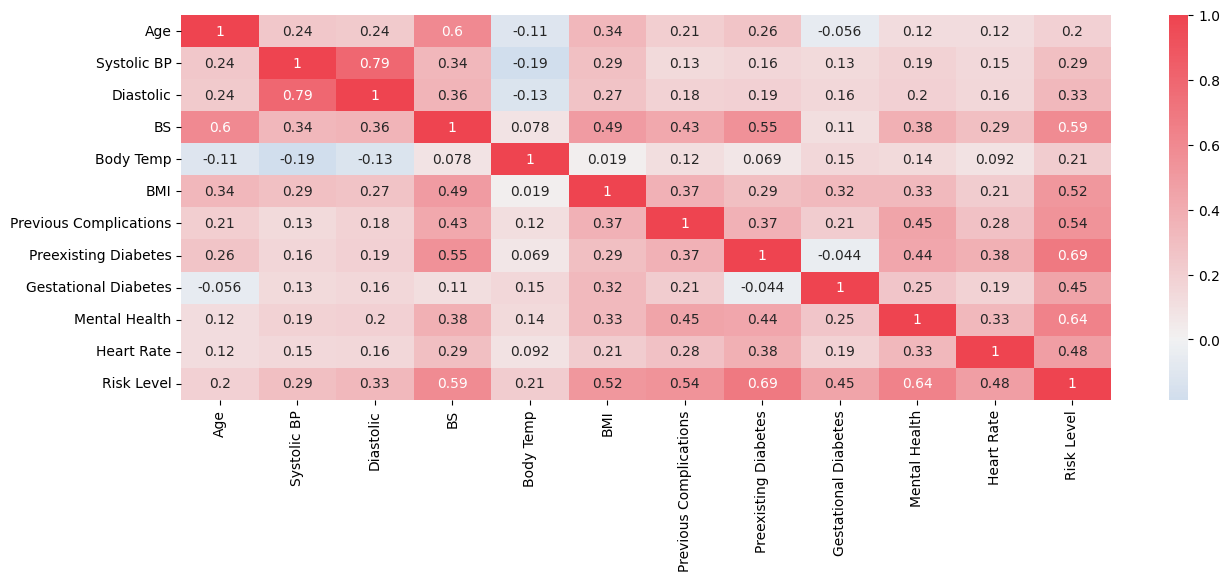

In [149]:
#correlation matrix
corrmat= data.corr()
plt.figure(figsize=(15,5))  

cmap = sns.diverging_palette(250, 10, s=80, l=55, n=9, as_cmap=True)

sns.heatmap(corrmat,annot=True, cmap=cmap, center=0)

### *CORRELATION WITH THE TARGET VARIABLE*

### For NUMERICAL columns

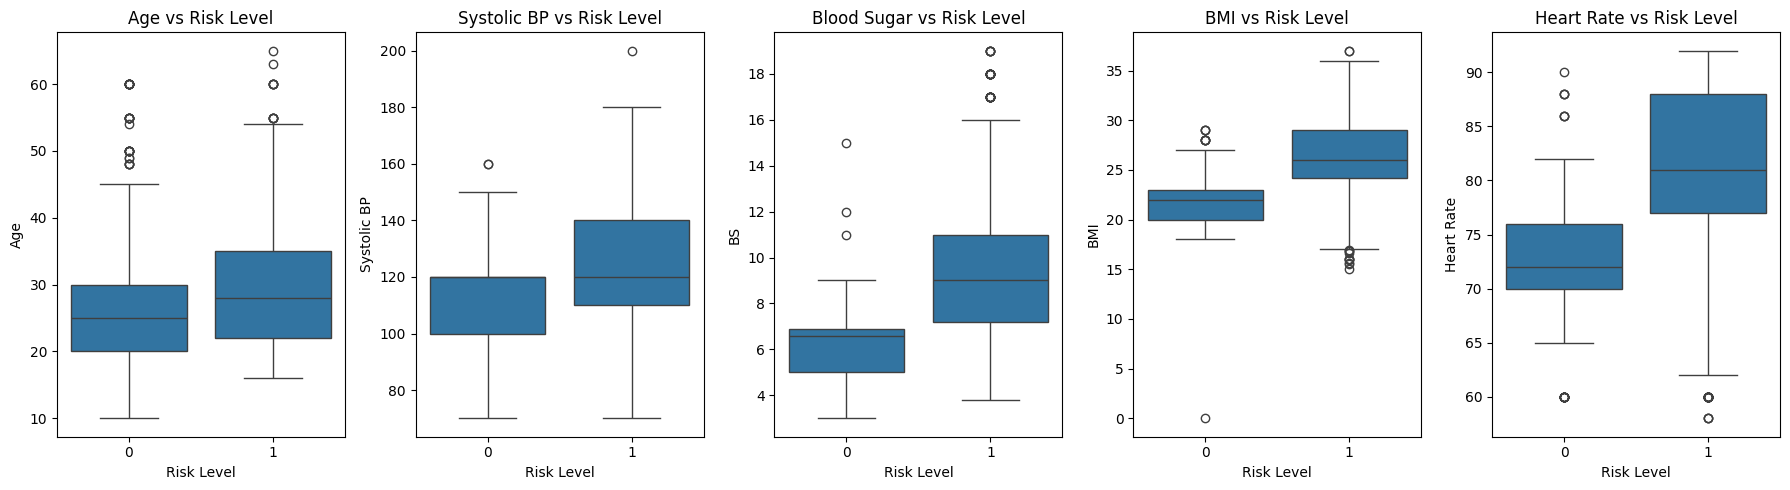

In [150]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

sns.boxplot(x='Risk Level', y='Age', data=data, ax=axes[0])
axes[0].set_title('Age vs Risk Level')

sns.boxplot(x='Risk Level', y='Systolic BP', data=data, ax=axes[1])
axes[1].set_title('Systolic BP vs Risk Level')

sns.boxplot(x='Risk Level', y='BS', data=data, ax=axes[2])
axes[2].set_title('Blood Sugar vs Risk Level')

sns.boxplot(x='Risk Level', y='BMI', data=data, ax=axes[3])
axes[3].set_title('BMI vs Risk Level')

sns.boxplot(x='Risk Level', y='Heart Rate', data=data, ax=axes[4])
axes[4].set_title('Heart Rate vs Risk Level')


plt.tight_layout()
plt.show()

### For categorical variables

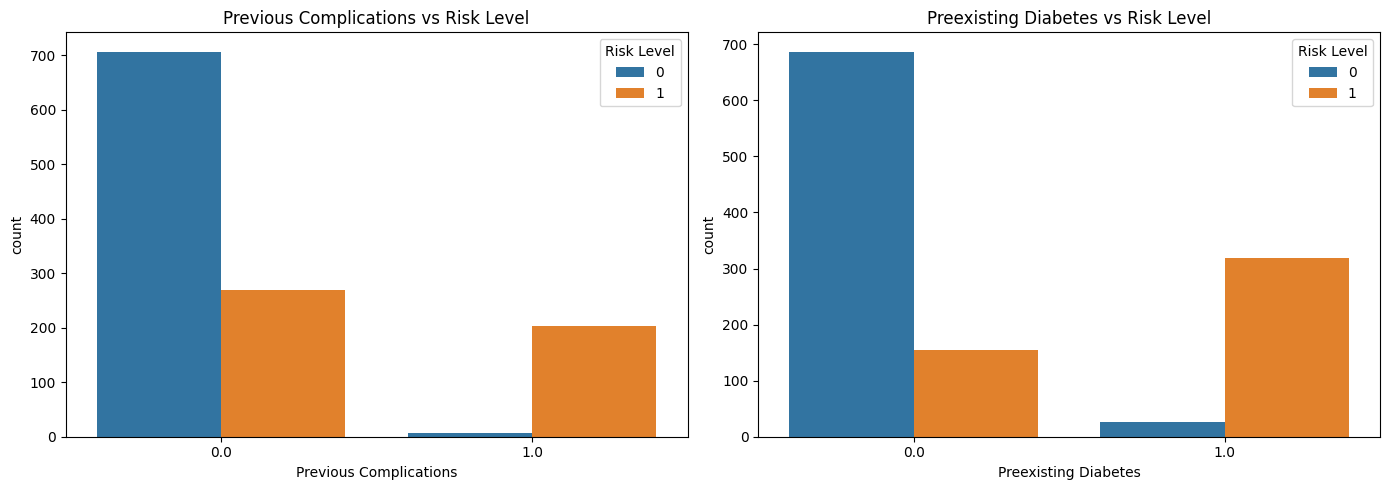

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Previous Complications', hue='Risk Level', data=data, ax=axes[0])
axes[0].set_title('Previous Complications vs Risk Level')

sns.countplot(x='Preexisting Diabetes', hue='Risk Level', data=data, ax=axes[1])
axes[1].set_title('Preexisting Diabetes vs Risk Level')

plt.tight_layout()
plt.show()

### *CUMULATIVE VISUALIZATION*

To better understand the distribution of numerical features across different maternal risk levels, we use a combination of boxenplots and swarmplots.

The boxenplot provides a detailed view of the data distribution, while the swarmplot overlays individual observations, offering insight into data density and variability.

This combined visualization helps identify patterns, outliers, and differences between risk categories.

In [152]:
numeric_cols = [
    col for col in data.select_dtypes(include=['float64', 'int64']).columns
    if col not in ['Risk Level']
]

In [153]:
data_melted = data[numeric_cols].melt(var_name='Feature', value_name='Value')

C:\Users\delll\AppData\Local\Temp\ipykernel_47828\1135614213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(
C:\Users\delll\AppData\Local\Temp\ipykernel_47828\1135614213.py:5: UserWarning: 
The palette list has fewer values (5) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.boxenplot(


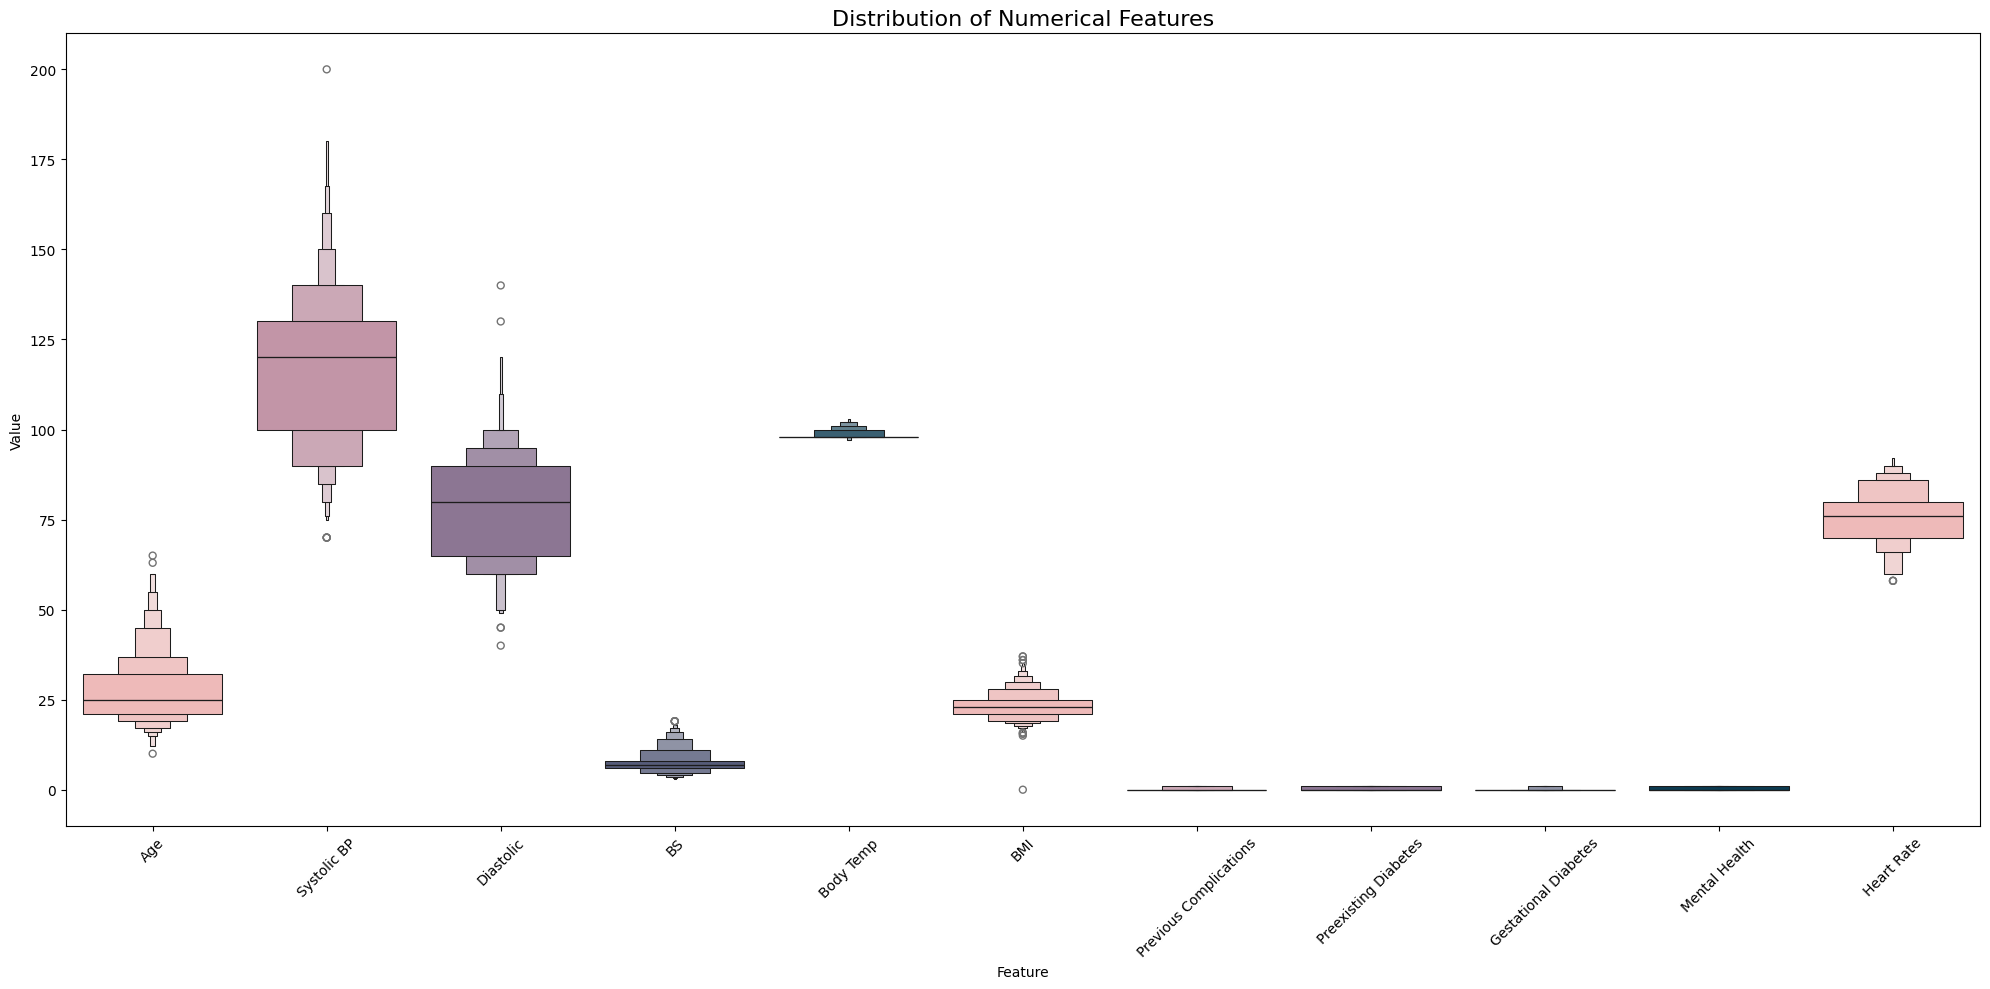

In [154]:
shades = ["#f7b2b0","#c98ea6","#8f7198","#50587f", "#003f5c"]

plt.figure(figsize=(20,10))

sns.boxenplot(
    x='Feature',
    y='Value',
    data=data_melted,
    palette=shades
)

plt.xticks(rotation=45)
plt.title("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()
plt.show()

## **<span style="color:#003366;"> MODELLING </span>**

In this section we will do the following activities:
* Set up features (`X`) and target (`y`)
* Split the data into stratified training and test sets
* Build a preprocessing pipeline with imputation, scaling, and encoding
* Compare candidate models using cross-validation
* Tune the best-performing model


In [155]:
# Feature selection
X = data.drop('Risk Level', axis=1)
y = data['Risk Level']

# Train-test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [156]:
categorical_cols = [
    'Previous Complications',
    'Preexisting Diabetes',
    'Gestational Diabetes',
    'Mental Health'
]

numeric_cols = [col for col in X.columns if col not in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

### *MODEL COMPARISON USING PIPELINES*

To identify the best-performing model, multiple classification algorithms are evaluated using pipelines. Each pipeline integrates preprocessing steps and the model, ensuring consistent data transformation and preventing data leakage.

The models compared include Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVC).

Cross-validation is used to assess model performance, providing a more robust estimate of accuracy across different data splits.

In [157]:
# Pipelines WITH preprocessing
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('lr_classifier', LogisticRegression(max_iter=1000, random_state=42))
])
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('dt_classifier', DecisionTreeClassifier(random_state=42))
])
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('rf_classifier', RandomForestClassifier(random_state=42))
])
pipeline_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('svc_classifier', SVC())
])
# List of pipelines
pipelines = [pipeline_lr, pipeline_dt, pipeline_rf, pipeline_svc]

# Dictionary for names
pipe_dict = {
    0: 'Logistic Regression',
    1: 'Decision Tree',
    2: 'Random Forest',
    3: 'SVC'
}
# Cross-validation on training data only
cv_results_accuracy = []
for i, model in enumerate(pipelines):
    cv_score = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
    cv_results_accuracy.append(cv_score)
    print(f"{pipe_dict[i]}: {cv_score.mean():.4f}")


Logistic Regression: 0.9599
Decision Tree: 0.9684
Random Forest: 0.9852
SVC: 0.9747


Random Forest remains the strongest candidate, so we tune it and then evaluate the tuned pipeline on the held-out stratified test set.


### *HYPERPARAMETER TUNING USING GridSearchCV*

`GridSearchCV` is used to optimize the Random Forest pipeline by testing multiple combinations of hyperparameters. Because preprocessing is included inside the pipeline, every cross-validation fold applies imputation, scaling, and encoding using only the training portion of that fold.

The best-performing configuration is selected based on cross-validation accuracy.


In [158]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV Score: 0.9831467557783347


### *FINAL MODEL FIT*

The tuned pipeline is fit on the full training split before generating predictions on the held-out test set.


In [165]:
best_model.fit(X_train, y_train)
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### *SAVING THE TRAINED MODEL*

The tuned preprocessing-and-model pipeline can be saved to disk and loaded later for inference without retraining.


In [166]:
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

model_path = model_dir / "maternal_risk_model.joblib"
joblib.dump(best_model, model_path)

print(f"Model saved to: {model_path.resolve()}")

Model saved to: C:\Users\delll\Desktop\DATA PROJECTS\Maternal pregnancy risks\models\maternal_risk_model.joblib


### *FINAL MODEL PERFORMANCE ON THE TEST SET*

In [167]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.9915966386554622

Confusion Matrix:
 [[142   1]
 [  1  94]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       143
           1       0.99      0.99      0.99        95

    accuracy                           0.99       238
   macro avg       0.99      0.99      0.99       238
weighted avg       0.99      0.99      0.99       238



## *FEATURE IMPORTANCE ANALYSIS*

Feature importance analysis was conducted using the tuned Random Forest pipeline to identify the most influential predictors of maternal risk.

The results highlight which clinical and historical variables contribute most strongly after consistent preprocessing has been applied.


In [168]:
# Get feature names after preprocessing
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance from Random Forest
importances = best_model.named_steps['model'].feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort descending
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
5,num__BMI,0.207363
3,num__BS,0.197508
8,cat__Preexisting Diabetes_1.0,0.167550
6,num__Heart Rate,0.135475
10,cat__Mental Health_1.0,0.104736
9,cat__Gestational Diabetes_1.0,0.072829
7,cat__Previous Complications_1.0,0.042413
1,num__Systolic BP,0.022737
0,num__Age,0.020542
2,num__Diastolic,0.019838


### *VISUALIZING FEATURE IMPORTANCE*

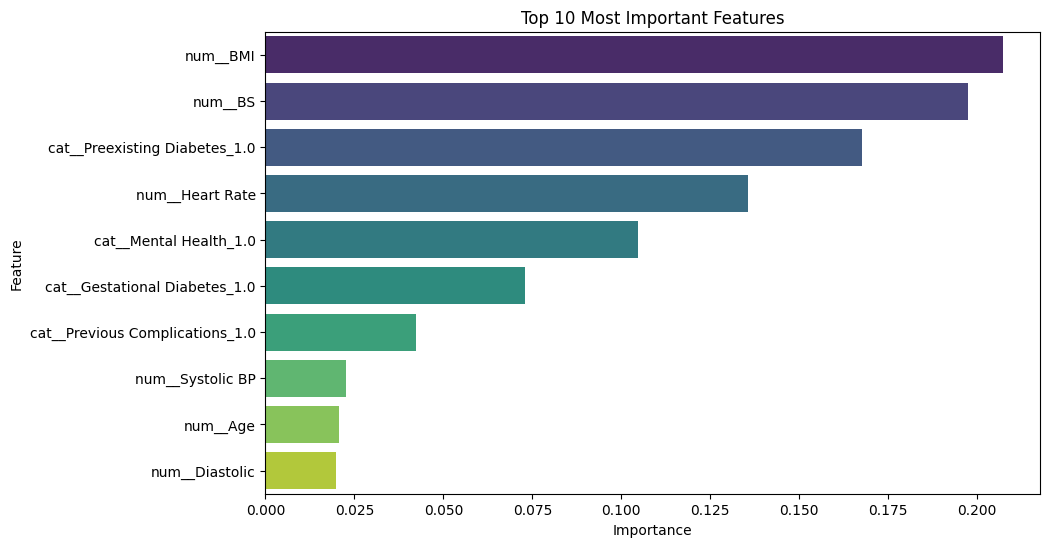

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

top_features = feat_imp.head(10).copy()

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=top_features,
    palette="viridis",
    dodge=False,
    legend=False
)

plt.title("Top 10 Most Important Features")
plt.show()


### *THE ROC CURVE*

The ROC curve summarizes how well the final model separates high-risk from low-risk cases across different probability thresholds.


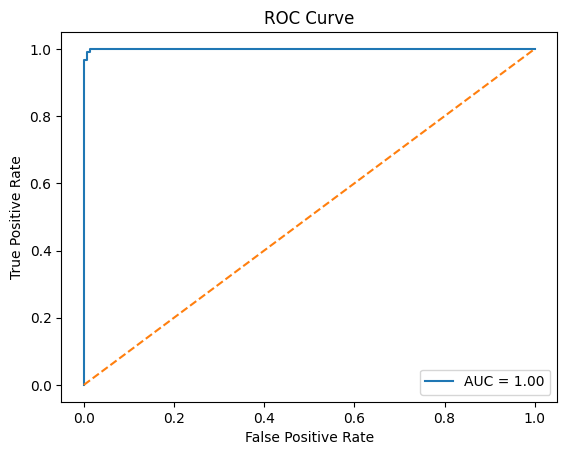

In [170]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### *PREDICTION INTERPRETATION*

Our Random Forest pipeline identifies blood sugar, BMI, preexisting diabetes, and heart rate as strong predictors of maternal risk. These features point to the importance of metabolic and physiological factors in pregnancy risk assessment.

Because the evaluation avoids leakage and uses a stratified split, the reported performance is more reliable and better reflects how the model may behave on unseen data.


## **<span style="color:#003366;"> PROJECT LIMITATIONS </span>**

- The dataset may not fully represent local Rwandan populations
- Some features may be correlated, affecting interpretability
- The dataset size is relatively limited
- Model performance may not generalize to real-world hospital settings without validation

## **<span style="color:#003366;"> FUTURE WORK </span>**

- Validate the model using local hospital data in Rwanda
- Integrate the model into clinical decision support systems
- Explore deep learning approaches
- Develop a mobile or web-based tool for real-time risk prediction

## **<span style="color:#003366;"> CONCLUSION </span>**

This project developed a machine learning pipeline for predicting maternal risk using clinical and demographic data. Through exploratory analysis, leakage-safe preprocessing, model comparison, and hyperparameter tuning, Random Forest emerged as the strongest model in this workflow.

After correcting the evaluation setup, the final pipeline still achieved very strong performance, with cross-validation accuracy around 98.3% and test accuracy around 99.2%, while providing a more trustworthy estimate of real-world behavior.


In case you have any comment, question or additions, please reach out to me here:
* **Whatsapp**: +250788369461
* **LinkedIn**: https://www.linkedin.com/in/iradukunda-protogene-6aa72912a/ 
* **GitHub**: https://github.com/Protos011 

## **<span style="color:#003366;"> THANK YOU </span>**